# Análise Exploratória da Série Temporal de CO₂

Este notebook apresenta uma análise exploratória da série temporal de concentração atmosférica de CO₂, com foco na identificação dos principais padrões presentes ao longo do tempo.

A análise contempla:

* validação inicial da série tratada;
* estatísticas descritivas;
* visualização da evolução temporal;
* análise de tendência por meio de médias móveis e médias anuais;
* investigação da sazonalidade;
* decomposição da série em tendência, sazonalidade e resíduo;
* análise do componente residual;
* verificação de estacionariedade com o teste ADF;
* análise das funções ACF e PACF;
* aplicação de diferenciação regular e sazonal para preparação da série para modelagem.

O objetivo desta etapa é compreender a estrutura temporal dos dados e identificar transformações necessárias antes da aplicação dos modelos estatísticos de forecasting.


## Importando as Bibliotecas

Nesta etapa, são carregadas as bibliotecas necessárias para manipulação dos dados, visualização, decomposição da série, análise de autocorrelação e teste de estacionariedade.

In [ ]:
# Manipulação e processamento dos dados
import pandas as pd
import numpy as np

# Visualização gráfica
import matplotlib.pyplot as plt

# Carregamento de datasets
from statsmodels.datasets import get_rdataset

# Análise de autocorrelação
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Decomposição da série temporal
from statsmodels.tsa.seasonal import seasonal_decompose

# Teste de estacionariedade
from statsmodels.tsa.stattools import adfuller

# 1. Carregamento e Validação Inicial dos Dados

Nesta etapa, o dataset tratado é carregado para a análise exploratória. Em seguida, é realizada uma validação rápida para confirmar a estrutura temporal, a ausência de valores ausentes e a integridade do índice.

In [7]:
# Importando a base de dados limpa
dados = pd.read_csv("../data/co2_clean.csv", index_col=0, parse_dates=True)

dados.head()

,co2
1958-03-29,316.1
1958-04-05,317.3
1958-04-12,317.6
1958-04-19,317.5
1958-04-26,316.4


In [12]:
# Fazendo uma validação rápida

print(f"Classe do Index -> {type(dados.index)}")
print(f"\nShape -> {dados.shape}")

print(f"\nValores Ausentes:\n{dados.isna().sum()}")

print(f"\nOrdenado -> {dados.index.is_monotonic_increasing}")
print(f"Frequência -> {pd.infer_freq(dados.index)}")

print(
    f"\nPeríodo -> "
    f"{dados.index.min().date()} até {dados.index.max().date()}"
)

Classe do Index -> <class 'pandas.DatetimeIndex'>

Shape -> (2284, 1)

Valores Ausentes:
co2    0
dtype: int64

Ordenado -> True
Frequência -> W-SAT

Período -> 1958-03-29 até 2001-12-29


### Observações

O dataset possui **2.284 observações**, sem valores ausentes, com índice do tipo `DatetimeIndex` e registros ordenados cronologicamente.

A frequência identificada é **semanal aos sábados (`W-SAT`)**, cobrindo o período de **1958-03-29 a 2001-12-29**.

Com essas validações, os dados estão prontos para a análise exploratória da série temporal.

# 2. Análise Exploratória

## 2.1 Estatísticas Descritivas

Nesta etapa, são analisadas as principais medidas estatísticas da concentração de CO₂, como média, mediana, desvio-padrão, valores mínimos, máximos e quartis.

Essas medidas ajudam a compreender a distribuição geral dos dados antes das análises temporais mais detalhadas.

In [13]:
print("=== Estatísticas Descritivas ===")
print(dados.describe().round(2))

=== Estatísticas Descritivas ===
           co2
count  2284.00
mean    339.65
std      17.10
min     313.00
25%     323.98
50%     337.70
75%     354.50
max     373.90


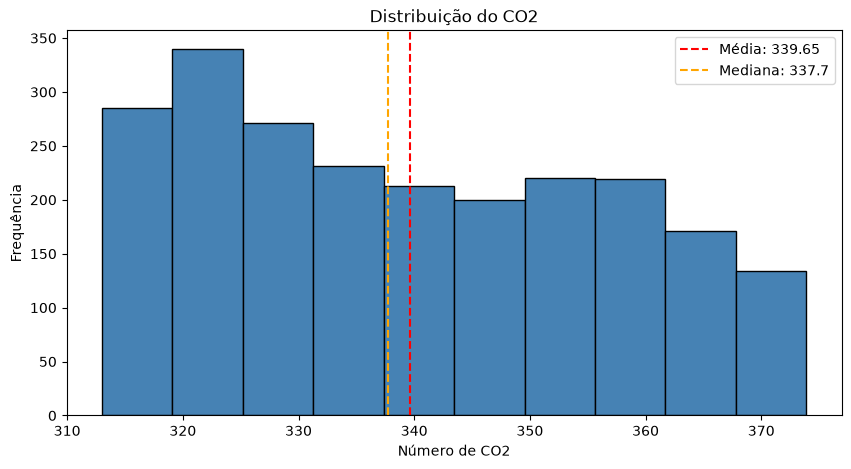

In [45]:
plt.figure(figsize=(10,5))

plt.hist(dados['co2'], color='steelblue', edgecolor='black')
plt.axvline(dados['co2'].mean(), color='red', linestyle='--', label=f'Média: {dados['co2'].mean().round(2)}')
plt.axvline(dados['co2'].median(), color='orange', linestyle='--', label=f'Mediana: {dados['co2'].median()}')

plt.title('Distribuição do CO2')
plt.xlabel('Número de CO2')
plt.ylabel('Frequência')
plt.legend()
plt.show()

### Observações

A concentração média de CO₂ é de aproximadamente **339,65**, enquanto a mediana é **337,70**.

Os valores variam entre **313,00** e **373,90**, mostrando uma amplitude considerável ao longo do período analisado.

A média ligeiramente superior à mediana indica uma leve assimetria na distribuição, o que também pode ser influenciado pela tendência crescente da série ao longo dos anos.

## 2.2 Visualização da Série Temporal

A série temporal é visualizada ao longo de todo o período disponível para identificar padrões gerais de comportamento.

O gráfico permite observar uma **tendência crescente de longo prazo** e oscilações sazonais recorrentes ao longo dos anos.

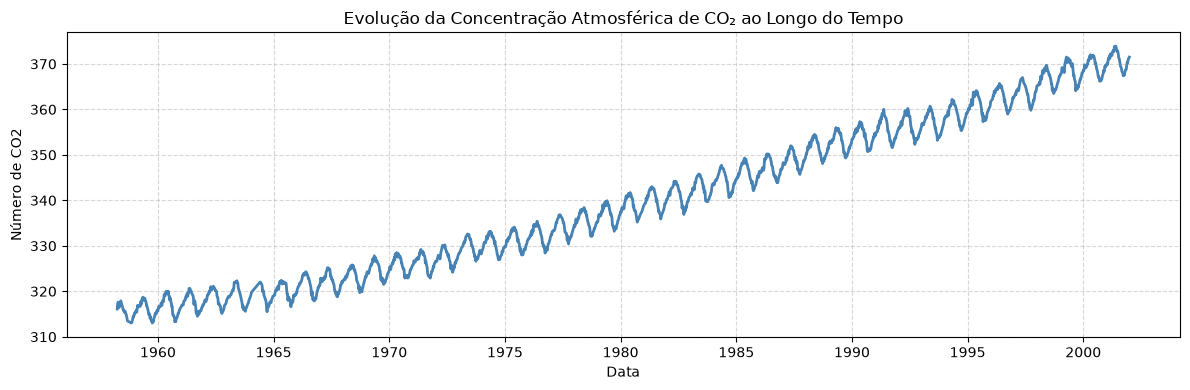

In [16]:
plt.figure(figsize=(12,4))

plt.plot(dados, color='steelblue', linewidth=2.0)
plt.title('Evolução da Concentração Atmosférica de CO₂ ao Longo do Tempo')
plt.xlabel('Data')
plt.ylabel('Número de CO2')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### 2.2.1 Médias Móveis

Para suavizar as oscilações de curto prazo e facilitar a identificação da tendência, foram calculadas médias móveis de **24 semanas** e **48 semanas**.

A média móvel de 24 semanas acompanha mais de perto as variações da série, enquanto a média de 48 semanas produz uma suavização maior e destaca melhor o comportamento de longo prazo.

In [19]:
dados_mm = dados.copy()

# 24 semanas ≈ 6 meses
dados_mm['dados_mm24_semanas'] = dados['co2'].rolling(24).mean()
# 48 semanas ≈ 1 ano
dados_mm['dados_mm48_semanas'] = dados['co2'].rolling(48).mean()
dados_mm.dropna(inplace=True)

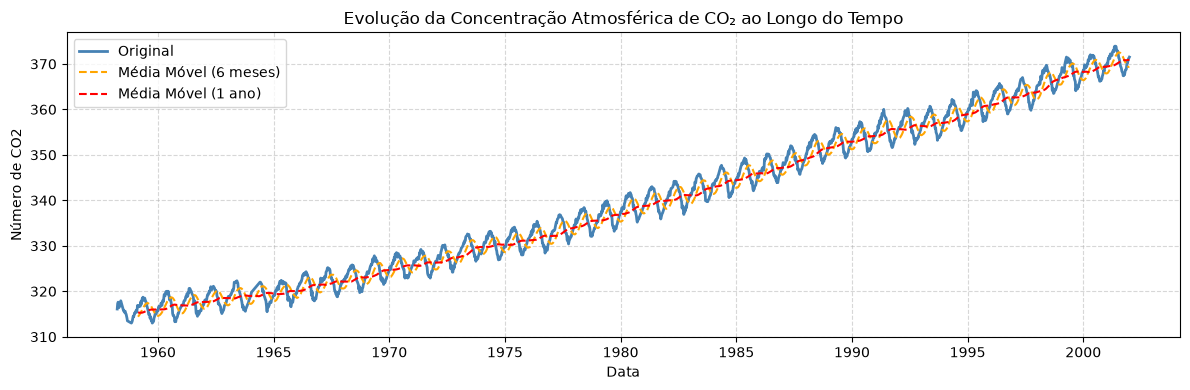

In [20]:
plt.figure(figsize=(12,4))

plt.plot(dados, color='steelblue', linewidth=2.0, label='Original')
plt.plot(dados_mm['dados_mm24_semanas'], color='orange', linestyle='--', linewidth=1.5, label='Média Móvel (6 meses)')
plt.plot(dados_mm['dados_mm48_semanas'], color='red', linestyle='--', linewidth=1.5, label='Média Móvel (1 ano)')
plt.title('Evolução da Concentração Atmosférica de CO₂ ao Longo do Tempo')
plt.xlabel('Data')
plt.ylabel('Número de CO2')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

### Observações

As médias móveis reforçam a presença de uma tendência crescente ao longo do tempo.

A série original apresenta oscilações sazonais bem definidas, enquanto as médias móveis reduzem essas variações e tornam a tendência de crescimento da concentração de CO₂ mais evidente.

## 2.3 Sazonalidade — Média por Mês do Ano

Para investigar possíveis padrões sazonais, foi calculada a concentração média de CO₂ para cada mês do ano.

A linha vermelha representa a média geral da série e serve como referência para comparar os meses com concentrações médias acima ou abaixo desse valor.

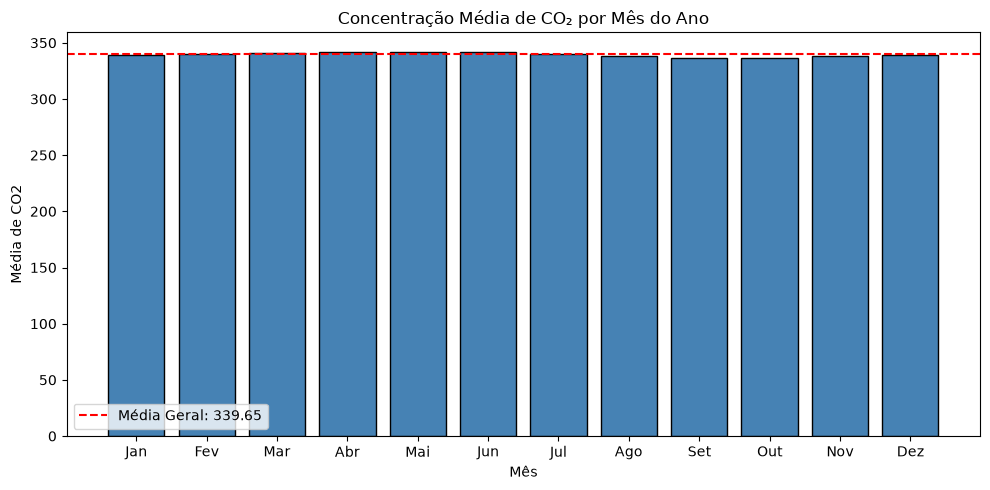

In [47]:
nomes_meses = ['Jan','Fev','Mar','Abr', 'Mai' ,'Jun' , 'Jul' ,'Ago' ,'Set' , 'Out' ,'Nov', 'Dez' ]
media_por_mes = dados.groupby(dados.index.month)['co2'].mean()

fig, ax = plt.subplots(figsize=(10,5))
ax.bar(nomes_meses, media_por_mes.values, color='steelblue', edgecolor='black')
ax.axhline(dados['co2'].mean(), color='red', linestyle='--', label=f'Média Geral: {dados['co2'].mean().round(2)}')
ax.set_title("Concentração Média de CO₂ por Mês do Ano")
ax.set_xlabel('Mês')
ax.set_ylabel('Média de CO2')
ax.legend()
plt.tight_layout()
plt.show()

### Observações

Os meses entre **março e junho** apresentam médias ligeiramente superiores, enquanto **agosto, setembro e outubro** apresentam valores médios mais baixos.

Esse comportamento sugere a presença de um padrão sazonal anual na série, que será analisado com mais detalhe na etapa de decomposição.

## 2.4 Tendência — Média por Ano

Para analisar a tendência de longo prazo, foi calculada a concentração média de CO₂ para cada ano da série.

Além da comparação com a média geral, também foi calculada a variação anual absoluta e percentual, permitindo observar a evolução da concentração de CO₂ ao longo do tempo.

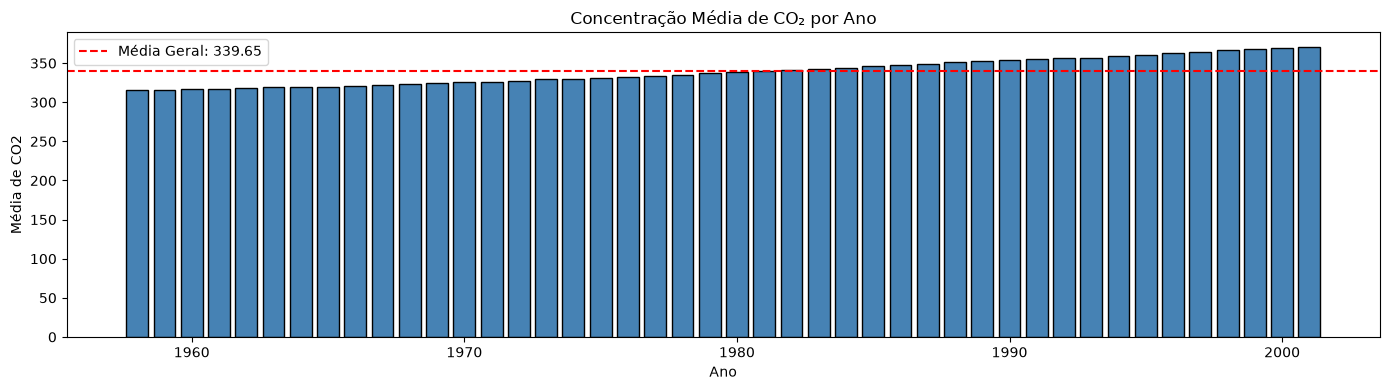

Variação anual da concentração média de CO₂:
1959 - 1 (0.24%)
1960 - 1 (0.29%)
1961 - 1 (0.23%)
1962 - 1 (0.27%)
1963 - 0 (0.15%)
1964 - 1 (0.18%)
1965 - 0 (0.15%)
1966 - 1 (0.42%)
1967 - 1 (0.26%)
1968 - 1 (0.27%)
1969 - 2 (0.49%)
1970 - 1 (0.33%)
1971 - 1 (0.20%)
1972 - 1 (0.35%)
1973 - 2 (0.68%)
1974 - 1 (0.17%)
1975 - 1 (0.27%)
1976 - 1 (0.30%)
1977 - 2 (0.53%)
1978 - 2 (0.48%)
1979 - 1 (0.40%)
1980 - 2 (0.54%)
1981 - 1 (0.36%)
1982 - 1 (0.35%)
1983 - 2 (0.48%)
1984 - 2 (0.48%)
1985 - 1 (0.44%)
1986 - 1 (0.36%)
1987 - 2 (0.52%)
1988 - 3 (0.73%)
1989 - 1 (0.41%)
1990 - 1 (0.36%)
1991 - 1 (0.40%)
1992 - 1 (0.21%)
1993 - 1 (0.19%)
1994 - 2 (0.52%)
1995 - 2 (0.55%)
1996 - 2 (0.49%)
1997 - 1 (0.31%)
1998 - 3 (0.78%)
1999 - 2 (0.45%)
2000 - 1 (0.31%)
2001 - 2 (0.41%)


In [50]:
media_por_ano = dados.groupby(dados.index.year)['co2'].mean()

fig, ax = plt.subplots(figsize=(14,4))
ax.bar(media_por_ano.index, media_por_ano.values, color='steelblue', edgecolor='black')
ax.axhline(dados['co2'].mean(), color='red', linestyle='--', label=f'Média Geral: {dados['co2'].mean().round(2)}')
ax.set_title("Concentração Média de CO₂ por Ano")
ax.set_xlabel('Ano')
ax.set_ylabel('Média de CO2')
ax.legend()
plt.tight_layout()
plt.show()

print("Variação anual da concentração média de CO₂:")
for i in range(1, len(media_por_ano)):
    delta = media_por_ano.iloc[i] - media_por_ano.iloc[i-1]
    pct = delta / media_por_ano.iloc[i-1] * 100
    print(f"{media_por_ano.index[i]} - {delta:.0f} ({pct:.2f}%)")

### Observações

A média anual de CO₂ apresenta um **crescimento consistente ao longo dos anos**, reforçando a presença de uma tendência de alta na série.

Os valores passam gradualmente de níveis próximos de 315 no início da série para valores superiores a 370 ao final do período analisado.

As variações anuais são relativamente pequenas em termos percentuais, mas se acumulam ao longo do tempo, resultando em um aumento expressivo da concentração atmosférica de CO₂.

## 2.5 Decomposição da Série

A série temporal foi decomposta em três componentes principais: **tendência**, **sazonalidade** e **resíduo**.

Foi utilizado um modelo **aditivo** com período de **52 semanas**, considerando que os dados possuem frequência semanal e apresentam um padrão sazonal aproximadamente anual.

In [25]:
decomp_adit = seasonal_decompose(dados, model='additive', period=52)

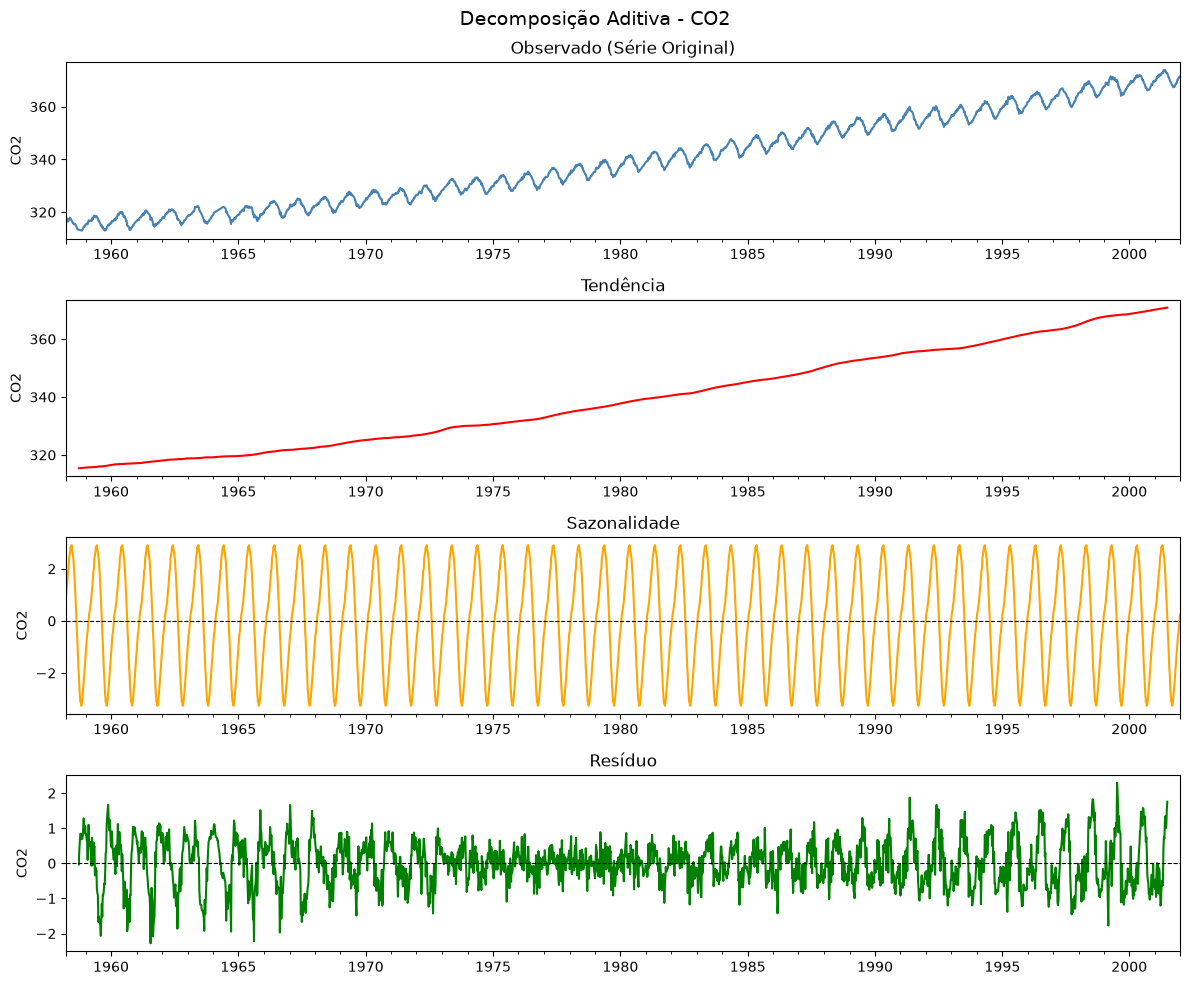

In [28]:
fig, ax = plt.subplots(4, 1, figsize=(12,10))

decomp_adit.observed.plot(ax=ax[0], color='steelblue')
ax[0].set_title('Observado (Série Original)')
ax[0].set_ylabel('CO2')

decomp_adit.trend.plot(ax=ax[1], color='red')
ax[1].set_title('Tendência')
ax[1].set_ylabel('CO2')

decomp_adit.seasonal.plot(ax=ax[2], color='orange')
ax[2].set_title('Sazonalidade')
ax[2].set_ylabel('CO2')
ax[2].axhline(0.0, color='black', linewidth=0.8, linestyle='--')

decomp_adit.resid.plot(ax=ax[3], color='green')
ax[3].set_title('Resíduo')
ax[3].set_ylabel('CO2')
ax[3].axhline(0.0, color='black', linewidth=0.8, linestyle='--')

plt.suptitle('Decomposição Aditiva - CO2', fontsize=14)
plt.tight_layout()
plt.show()

### Observações

A decomposição evidencia uma **tendência crescente de longo prazo** na concentração de CO₂ e um **padrão sazonal anual bem definido**, que se repete de forma relativamente estável ao longo dos anos.

O componente residual permanece concentrado em torno de zero, representando variações que não foram explicadas pela tendência e pela sazonalidade.

## 2.6 Identificação da Sazonalidade — Análise de Dois Ciclos

Para visualizar com mais clareza o comportamento sazonal da série, foram selecionados dois ciclos anuais consecutivos do componente sazonal obtido na decomposição.

Essa visualização permite observar a repetição do padrão ao longo do ano e identificar os períodos em que a concentração de CO₂ tende a apresentar efeitos sazonais positivos ou negativos.

In [29]:
sazonalidade_ano = decomp_adit.seasonal['1960':'1961']

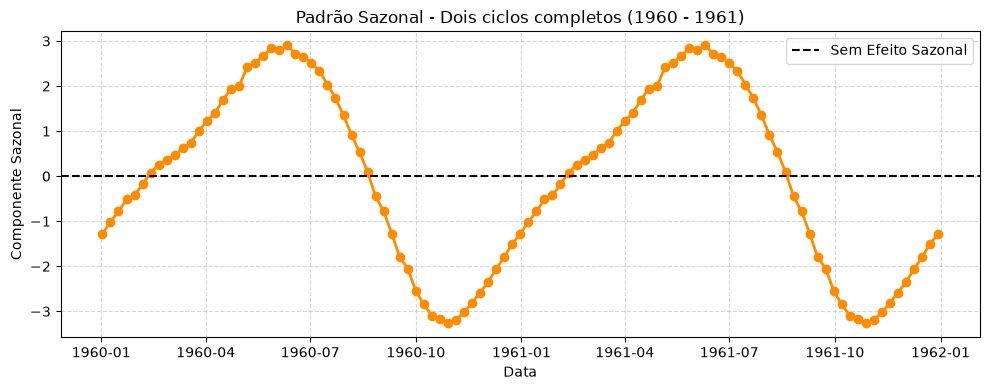

In [51]:
plt.figure(figsize=(10,4))
plt.plot(sazonalidade_ano, marker='o', color='darkorange', linewidth=2)
plt.axhline(0.0, color='black', linestyle='--', label='Sem Efeito Sazonal')
plt.title('Padrão Sazonal - Dois ciclos completos (1960 - 1961)')
plt.xlabel('Data')
plt.ylabel('Componente Sazonal')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Observações

O padrão sazonal se repete de forma bastante consistente entre os dois anos analisados.

Os maiores efeitos sazonais positivos ocorrem aproximadamente entre **maio e julho**, enquanto os menores valores aparecem entre **outubro e novembro**.

A repetição desse comportamento reforça a presença de uma sazonalidade anual bem definida na série.

## 2.7 Análise do Ruído (Resíduo)

Após a decomposição da série, o componente residual é analisado para verificar se ainda existe algum padrão sistemático não explicado pela tendência e pela sazonalidade.

Em um bom ajuste aditivo, espera-se que os resíduos apresentem média próxima de zero e comportamento aproximadamente aleatório ao longo do tempo.

In [32]:
residuos = decomp_adit.resid.dropna()

In [35]:
print('Estatísticas descritivas do resíduo (modelo aditivo):')
print(residuos.describe().round(4))
print("\nUm bom resíduo deve apresentar:")
print("- média próxima de zero")
print("- ausência de tendência")
print("- ausência de sazonalidade")
print("- baixa autocorrelação")

Estatísticas descritivas do resíduo (modelo aditivo):
count    2232.0000
mean        0.0042
std         0.6369
min        -2.2796
25%        -0.4274
50%         0.0078
75%         0.4280
max         2.2945
Name: resid, dtype: float64

Um bom resíduo deve apresentar:
- média próxima de zero
- ausência de tendência
- ausência de sazonalidade
- baixa autocorrelação


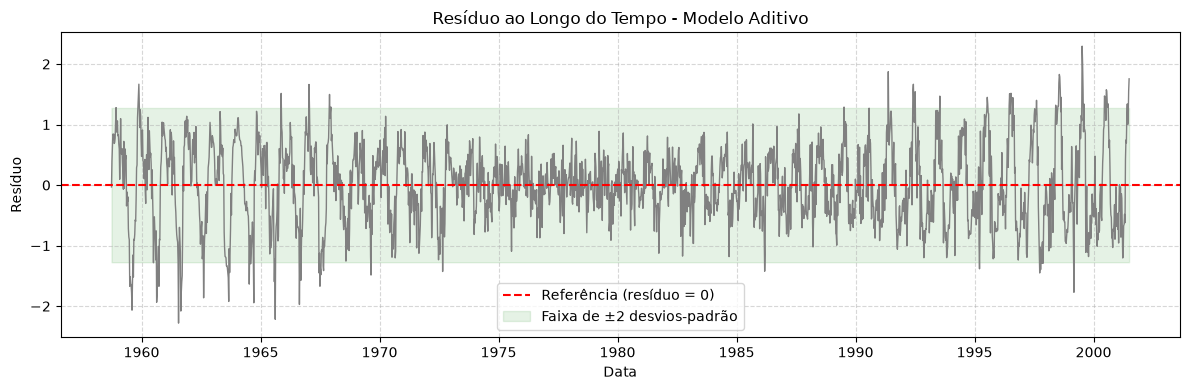

In [52]:
std_resid = residuos.std()
# Plota o resíduo ao longo do tempo para verificar se existe algum padrão sistemático.
# Em um modelo aditivo, espera-se que os resíduos oscilem em torno de 0.
# Pontos muito distantes da linha de referência podem indicar eventos incomuns.
plt.figure(figsize=(12, 4))
plt.plot(residuos, color='gray', linewidth=1)
plt.axhline(0.0, color='red', linestyle='--', linewidth=1.5, label='Referência (resíduo = 0)')
plt.fill_between(residuos.index, -2 * std_resid, 2 * std_resid, alpha=0.1, color='green', label='Faixa de ±2 desvios-padrão')
plt.title('Resíduo ao Longo do Tempo - Modelo Aditivo')
plt.xlabel('Data')
plt.ylabel('Resíduo')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Observações

Os resíduos apresentam média próxima de zero, o que é um comportamento desejável em uma decomposição aditiva.

Entretanto, ainda são observadas oscilações e alguns valores mais extremos ao longo do tempo. Por isso, a análise de autocorrelação será importante para verificar se ainda existe dependência temporal nos resíduos.

## 2.8 Verificação de Estacionariedade

Para verificar se a série é estacionária, foi aplicado o teste **Augmented Dickey-Fuller (ADF)**.

O teste avalia a hipótese nula de que a série possui raiz unitária, ou seja, não é estacionária. Assim, valores de `p-value` menores ou iguais a 0,05 indicam evidência a favor da estacionariedade.

In [38]:
# Teste ADF
adf_result = adfuller(dados['co2'])
print(f'ADF Statistic: {adf_result[0].round(4)}')
print(f'p-value: {adf_result[1].round(4)}') # p> 0.05 -> não é estacionária

if adf_result[1] > 0.05:
    print('\nA série provavelmente NÃO é estacionária (p-valor > 0.05).')
else:
    print('\nA série provavelmente é estacionária (p-valor <= 0.05).')

ADF Statistic: 0.0338
p-value: 0.9612

A série provavelmente NÃO é estacionária (p-valor > 0.05).


### Observações

O teste ADF apresentou `p-value = 0,9612`, valor muito superior a 0,05.

Portanto, não rejeitamos a hipótese nula e concluímos que a série original **não é estacionária**.

Esse resultado é coerente com a tendência crescente e a sazonalidade observadas anteriormente, indicando a necessidade de aplicar diferenciação antes da modelagem.

## 2.9 ACF e PACF

Nesta etapa, as funções de autocorrelação (ACF) e autocorrelação parcial (PACF) são utilizadas para avaliar a dependência temporal da série após diferentes processos de diferenciação.

O objetivo é verificar qual transformação reduz melhor a tendência e a sazonalidade antes da etapa de modelagem.

### 2.9.1 Diferenciação Regular

Primeiro, foi aplicada uma diferenciação de primeira ordem (`diff(1)`) para reduzir a tendência presente na série.

A ACF e a PACF foram analisadas considerando 52 lags, correspondentes a aproximadamente um ano de observações semanais.

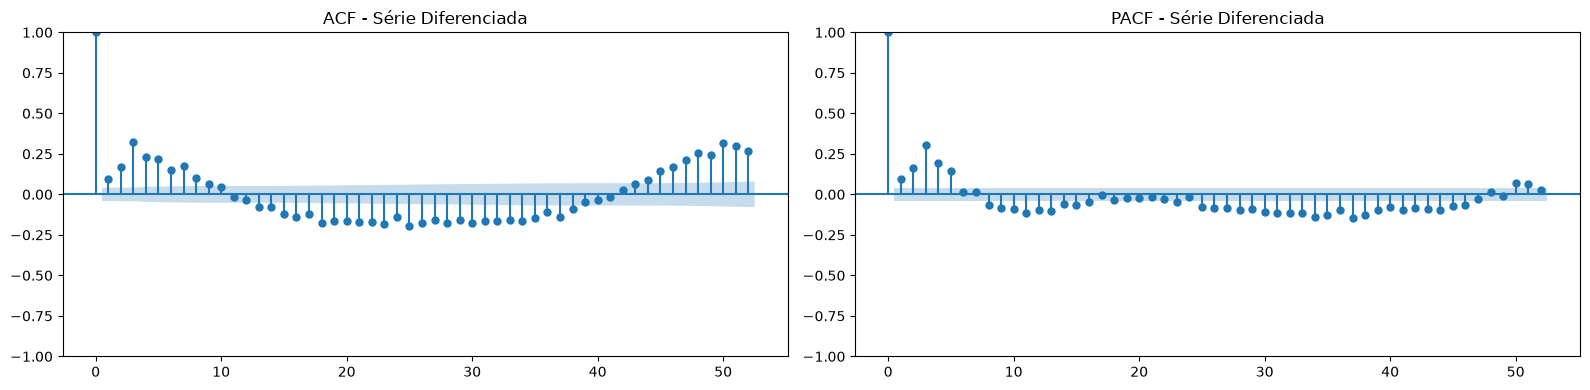

In [39]:
dados_diff = dados['co2'].diff().dropna()

fig, ax = plt.subplots(1, 2, figsize=(16,4))

plot_acf(dados_diff, lags=52, ax=ax[0], title='ACF - Série Diferenciada')

plot_pacf(dados_diff, lags=52, ax=ax[1], title='PACF - Série Diferenciada')

plt.tight_layout()
plt.show()

**Observações**

A diferenciação regular reduziu a tendência, porém a ACF ainda apresenta um comportamento cíclico ao longo dos 52 lags.

Esse padrão indica que a sazonalidade anual ainda permanece presente na série.

### 2.9.2 Diferenciação Sazonal

Em seguida, foi aplicada uma diferenciação sazonal com período de 52 semanas (`diff(52)`), com o objetivo de reduzir o padrão anual identificado anteriormente.

In [40]:
serie_diff_sazonal = (dados["co2"].diff(52).dropna())

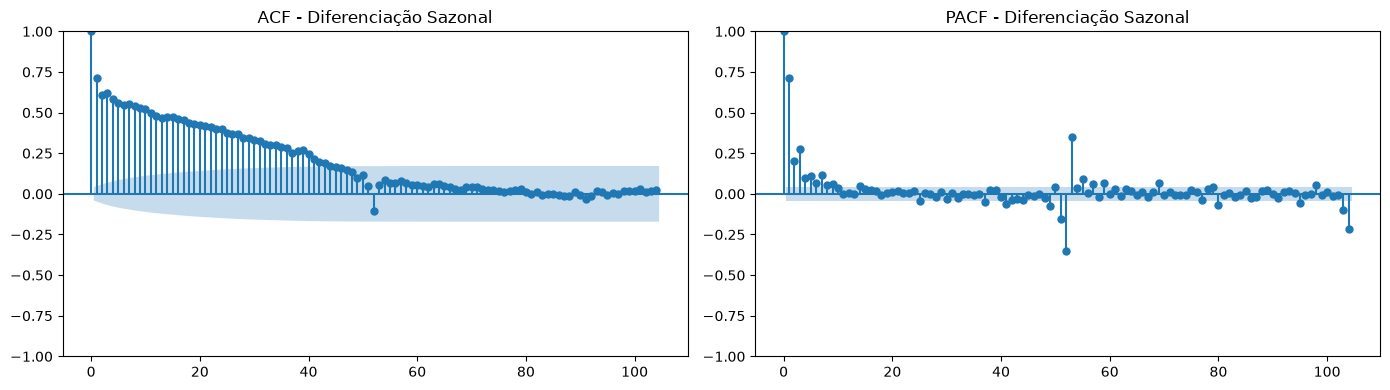

In [41]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(serie_diff_sazonal, lags=104, ax=ax[0], title="ACF - Diferenciação Sazonal")

plot_pacf(serie_diff_sazonal, lags=104, ax=ax[1], title="PACF - Diferenciação Sazonal")

plt.tight_layout()
plt.show()

**Observações**

A diferenciação sazonal reduziu parte da estrutura periódica anual.

Entretanto, a ACF ainda apresenta um decaimento lento nos primeiros lags, indicando que a série mantém dependência de longo prazo e que apenas a diferenciação sazonal não é suficiente.

#### 2.9.3 Diferenciação Regular + Sazonal

Como as transformações anteriores isoladamente não removeram completamente a estrutura da série, foram combinadas a diferenciação regular (`d=1`) e a diferenciação sazonal (`D=1`, período de 52 semanas).

In [42]:
serie_diff_completa = (
    dados["co2"]
    .diff()      # diferenciação comum
    .diff(52)    # diferenciação sazonal
    .dropna()
)

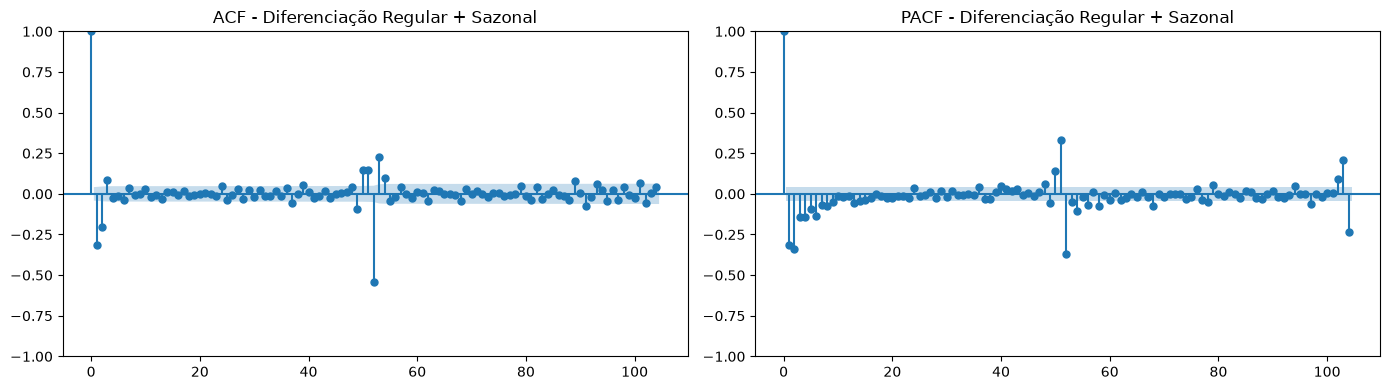

In [43]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(serie_diff_completa, lags=104, ax=ax[0], title="ACF - Diferenciação Regular + Sazonal")

plot_pacf(serie_diff_completa, lags=104, ax=ax[1], title="PACF - Diferenciação Regular + Sazonal")

plt.tight_layout()
plt.show()

**Observações**

Após a combinação das duas diferenciações, a maior parte das autocorrelações passou a permanecer próxima de zero.

Esse comportamento indica uma redução significativa da tendência e da sazonalidade, deixando a série mais próxima de um processo estacionário.

Ainda são observados alguns picos nos primeiros lags e próximos ao período sazonal de 52 semanas, que poderão auxiliar na definição dos parâmetros dos modelos SARIMA.

### 2.9.4 Validação da Estacionariedade

Após a diferenciação regular e sazonal, o teste Augmented Dickey-Fuller (ADF) foi aplicado novamente para verificar se a série transformada apresenta comportamento estacionário.

In [44]:
adf_result = adfuller(serie_diff_completa)

print(f"ADF Statistic: {adf_result[0]:.4f}")
print(f"p-value: {adf_result[1]:.4f}")

ADF Statistic: -17.1904
p-value: 0.0000


**Resultado**

O teste apresentou `ADF Statistic = -17,1904` e `p-value ≈ 0,0000`.

Como o `p-value` é inferior a 0,05, rejeitamos a hipótese nula de presença de raiz unitária.

Portanto, a série após as diferenciações apresenta evidências de **estacionariedade** e está mais adequada para a etapa de modelagem.

# Conclusão da Análise Exploratória

A análise exploratória permitiu identificar os principais padrões presentes na série temporal de concentração atmosférica de CO₂.

Foi observada uma **tendência crescente de longo prazo**, acompanhada por uma **sazonalidade anual bem definida**. A decomposição aditiva confirmou essa estrutura, separando a série em componentes de tendência, sazonalidade e resíduo.

O teste ADF aplicado à série original indicou ausência de estacionariedade. Após a aplicação conjunta de uma diferenciação regular e uma diferenciação sazonal de 52 semanas, a série passou a apresentar comportamento significativamente mais estável, com `p-value` inferior a 0,05 no teste ADF.

As análises de ACF e PACF também mostraram que ainda existem dependências temporais relevantes, especialmente próximas ao período sazonal anual, fornecendo informações importantes para a definição dos parâmetros dos modelos de forecasting.

Com isso, a série encontra-se devidamente compreendida e preparada para a próxima etapa do projeto: **construção, avaliação e comparação de modelos estatísticos e de Machine Learning para previsão da concentração de CO₂**.
